In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
import scipy as sp
import matplotlib.mlab as mlab
import matplotlib.artist as artist
from pathlib import Path
import tkinter as tk
from tkinter import filedialog

In [11]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [12]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if (str(i)[-9:] != 'Sheet.csv') == True]
files = [i for i in files if (str(i)[-3:] == 'csv') == True]
files

[WindowsPath('D:/Sofia/Data_Sheets_summer/Sofia_2020-07-03.csv')]

In [13]:
tubulin = '[Tubulin] ' r'$(\mu M)$'
tub = 'tub'

DCXconc = '[DCX] ' r'$(\mu M)$'
DCX = 'DCX'
Type = 'DCX Type'

Concentration = 'Concentration ' r'$(\mu M)$'
Length = 'Length ' r'$(\mu m)$'
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'

In [14]:
jointdate = ''

for i in files :
    dateloc = str(i).find("2020")
    date = str(i)[dateloc : dateloc+10]
    jointdate = jointdate+'_'+date
jointdate

'_2020-07-03'

In [15]:
data = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    data = data.append(d, ignore_index=True)
data.to_csv(path/('MasterSheet.csv'), encoding='utf-8', index=False)

In [16]:
data_mean = data.groupby(['Date', 'CH']).mean()
data_std = data.groupby(['Date', 'CH']).std()
data_mean

[Tubulin] $(\mu M)$  [DCX] $(\mu M)$  Length $(\mu m)$  \
Date       CH                                                           
2020-07-03 13                 12.0              0.0          3.411167   
           14                  8.0              0.0          2.504306   
           22                  6.0              0.0          0.292763   

               Lifetime $(min)$  Growth Rate $(\mu m / min)$  \
Date       CH                                                  
2020-07-03 13          6.101204                     0.555068   
           14          5.271021                     0.457049   
           22          1.970083                     0.167891   

               Time to Nucleate $(min)$  Shrink Length $(\mu m)$  \
Date       CH                                                      
2020-07-03 13                  0.705597                 3.488533   
           14                  2.433786                 2.545847   
           22                  6.573931                 0.348150   

               Shrink Lifetime $(min)$  Shrink Rate $(\mu m / min)$  Rescues  
Date       CH                                                                 
2020-07-03 13                 0.307389                    14.721706  0.00000  
           14                 0.254391                    11.614099  0.03125  
           22                 0.090282                     4.036718  0.00000

In [17]:
blue = '#23459C'
orange = '#FF7300'
green = '#79BA1A'

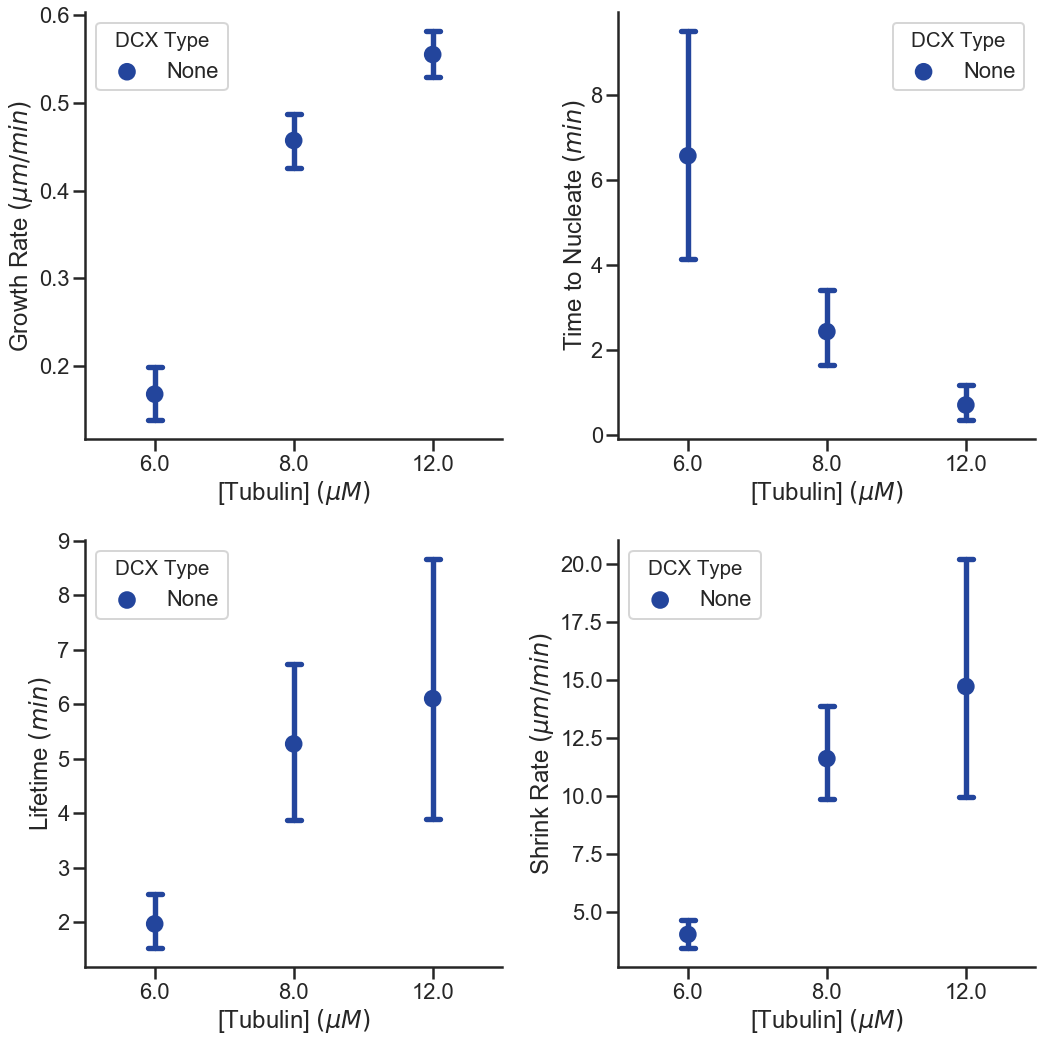

In [18]:
fig, axs = plt.subplots(2,2,figsize=(15,15))
palette = [blue,green,orange]
sns.set_style("ticks")
sns.pointplot(x=tubulin, y=GrowthRate,
                hue=Type,err_style="bars", marker='o', join=False, capsize=.1,
                data=data,err_kws={'capsize':10},ci=95 , palette=palette,ax=axs[0][0])
sns.pointplot(x=tubulin, y=TimeToNucleate,
                hue=Type,err_style="bars", marker='o', join=False, capsize=.1,
                data=data,err_kws={'capsize':10},ci=95 , palette=palette,ax=axs[0][1])
sns.pointplot(x=tubulin, y=Lifetime,
                hue=Type,err_style="bars", marker='o', join=False, capsize=.1,
                data=data,err_kws={'capsize':10},ci=95 , palette=palette,ax=axs[1][0])
sns.pointplot(x=tubulin, y=ShrinkageRate,
                hue=Type,err_style="bars", marker='o', join=False, capsize=.1,
                data=data,err_kws={'capsize':10},ci=95 , palette=palette,ax=axs[1][1])
sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()
plt.savefig(path/('plots'+jointdate+'.pdf'))
plt.savefig(path/('plots'+jointdate+'.png'))

# Fitting Data #

In [30]:
def make_hist(data, parameter, bins, constant) :
    fig, ax = plt.subplots(figsize=(15,15))
    sns.set_style("ticks")
    hist = data.hist(by=[Type,tubulin], column=parameter, bins = bins,density=True,ax=ax)
    fig.suptitle(parameter)
    
    sns.despine()
    sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    unique = data[DCXconc].unique()
    cte = [x if x > 0 else 0 for x in unique]
    
    return hist, cte[0],fig

In [20]:
def get_hist(ax):
    n,bins = [],[]
    for rect in ax.patches:
        
            ((x0, y0), (x1, y1)) = rect.get_bbox().get_points()
            n.append(y1-y0)
            bins.append(x0) # left edge of each bin
    
        #bins.append(x1) # also get right edge of last bin

    return n,bins


In [21]:
def gaussian(x, mu, sig):
    return (np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.))) )/(sig*np.sqrt(2*np.pi))

def exponential(x, scale):
    return ((np.exp(-x/scale) )/(scale))

def gamma(x, shape, scale):
    return (np.power(x,shape-1)*np.exp(-x/ scale))/(sp.special.gamma(shape) * np.power(scale,shape))


In [26]:
def equation_fit(data, parameter, equation, constant,maxbin,binsize):
    
    bins = np.arange(0, maxbin + binsize, binsize)
    hist, cte,fig = make_hist(data, parameter, bins, constant) 
    
    results = pd.DataFrame(columns=[] , index=[])
    
    for i in np.arange(0,len(hist[0][:])):
        for j in np.arange(0,len(hist[:][0])):
        
            n, bins =  get_hist(hist[j][i]);
            
            if n == []:
                break
            
            title = []
            title = hist[j][i].get_title()
            title = title[1:-1]
            title = title.split(',')
            
            if equation == gamma :
                coeff, var_matrix = sp.optimize.curve_fit(equation,bins,n,[2,1])
            else :
                coeff, var_matrix = sp.optimize.curve_fit(equation,bins,n)

            variance = np.diagonal(var_matrix) #Refer [3]
            SE = np.sqrt(variance) #Refer [4]

        #======Making a data frame========
            results0 = pd.DataFrame(columns=[] , index=[])
            for k in np.arange(0,len(coeff)):
                header = [np.array([parameter]),np.array(['Coefficient '+ str(k)])]
                r0 = pd.DataFrame([coeff[k],SE[k]], index=(['Value','SE']),columns= header)
                results0 = pd.concat([results0, r0], axis=1, sort=False)
            
            results0[tubulin] = float(title[1])
            if title[0] == 'None':
                results0[constant] = 0
            else:
                results0[constant] = cte
            results0[Type] = title[0]
            
            results = pd.concat([results, results0], sort=False)

    return results,fig

In [24]:
newmydir = path/('fitdata')
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('D:/Sofia/Data_Sheets_summer/fitdata')

C:\ProgramData\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\hist.py:385: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared
  **kwds
C:\ProgramData\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\hist.py:385: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared
  **kwds
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:8: RuntimeWarning: divide by zero encountered in power
  
C:\ProgramData\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\hist.py:385: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared
  **kwds


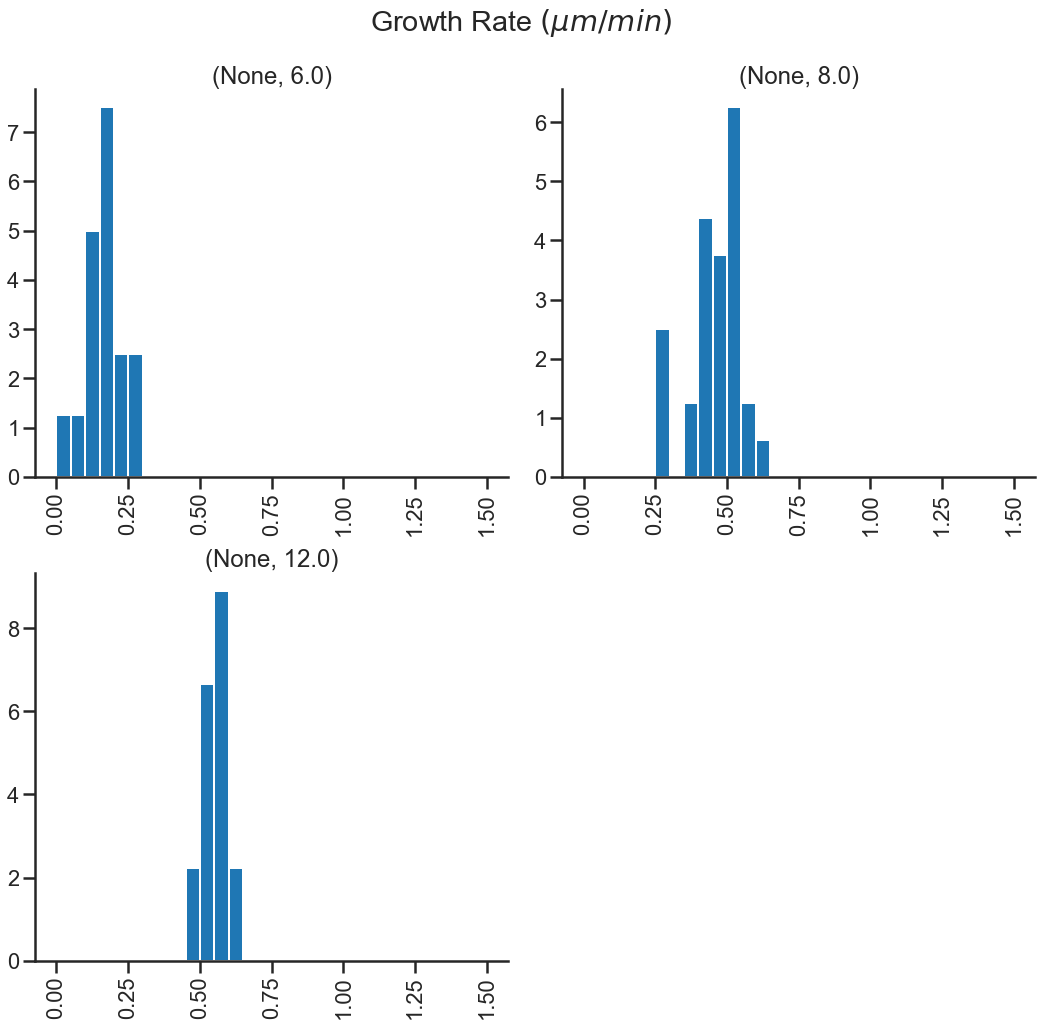

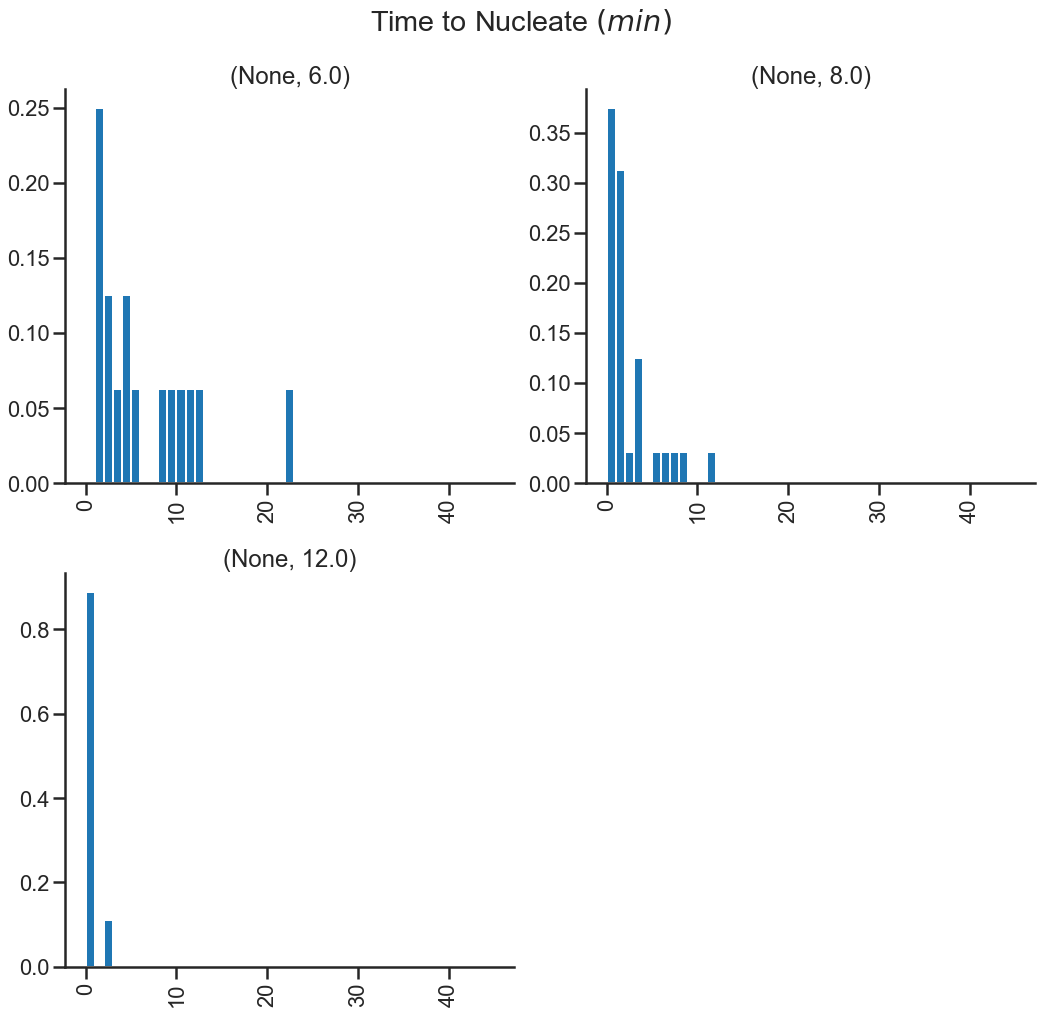

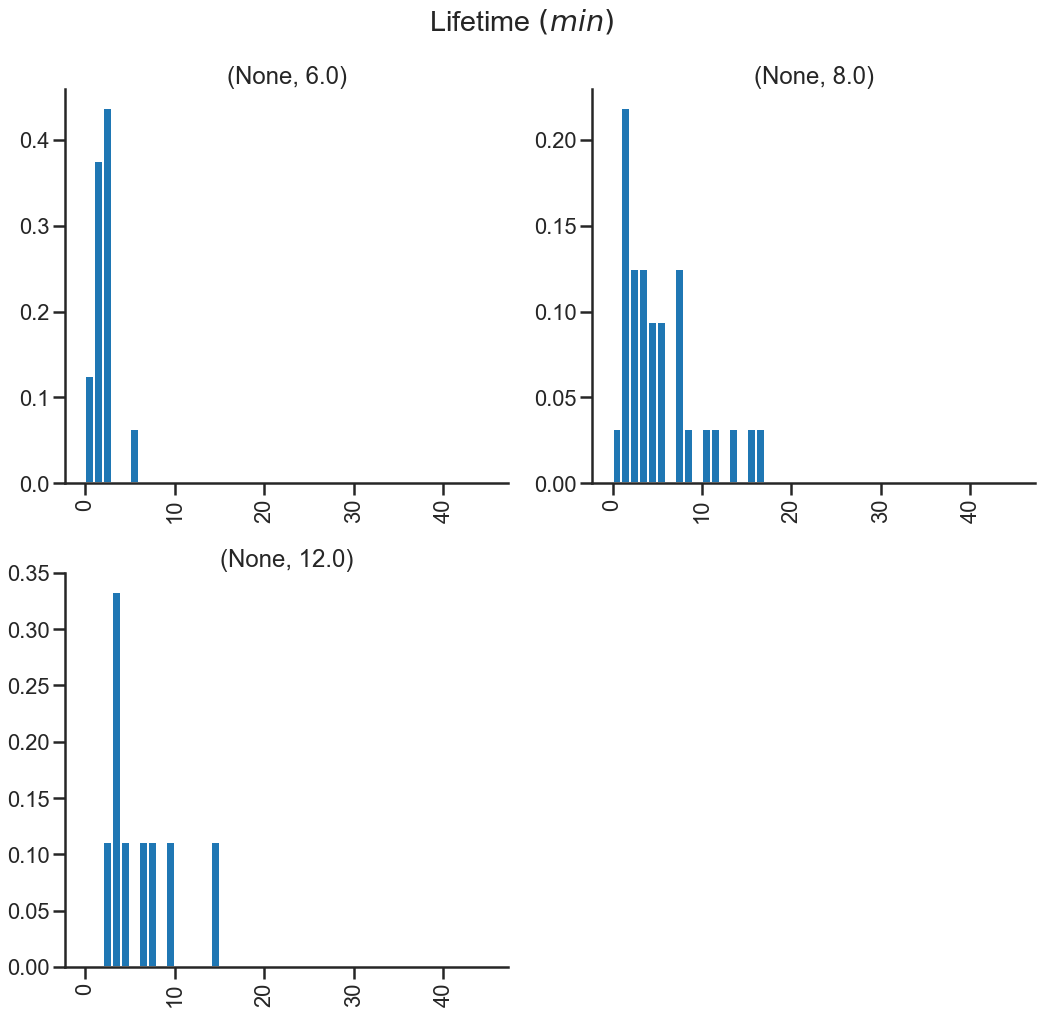

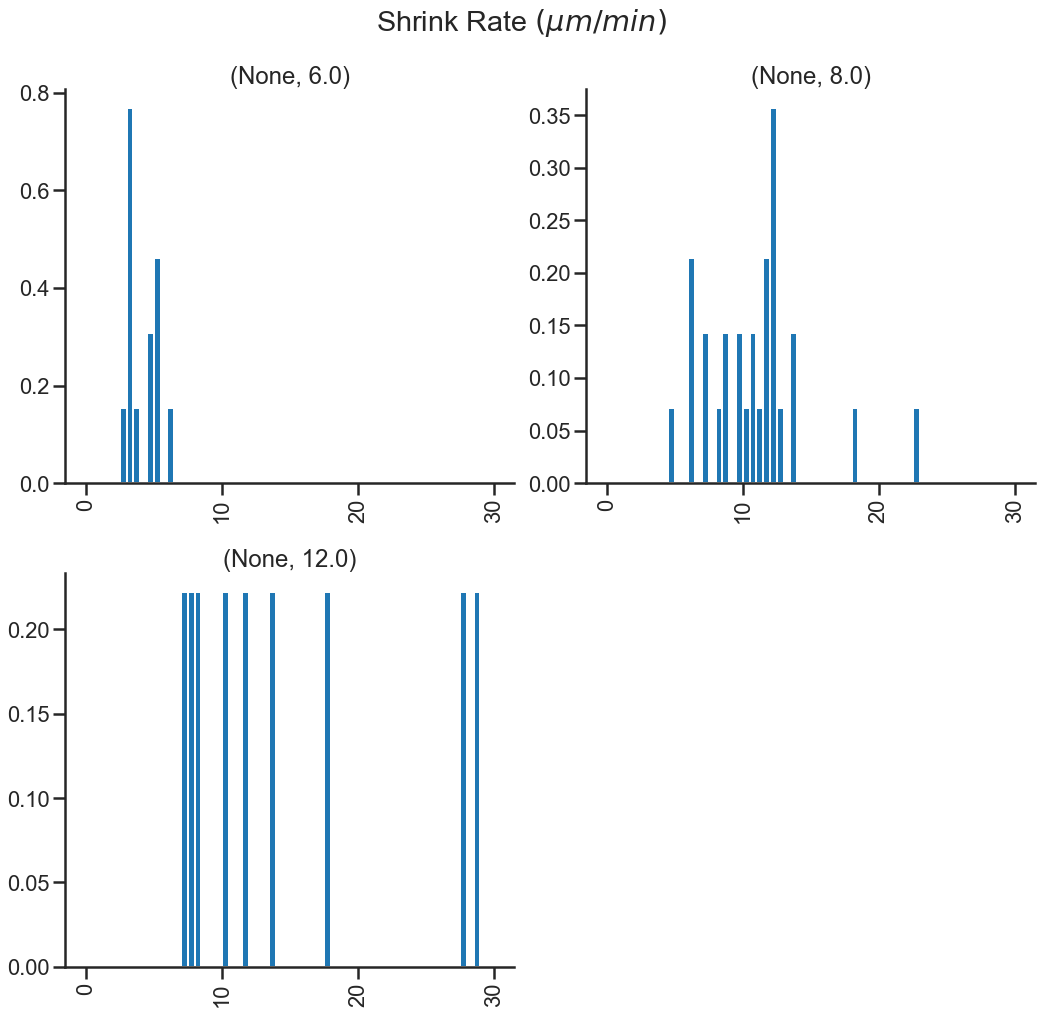

In [31]:
GrowthRateFit , GrowthRateFig = equation_fit(data,GrowthRate,gaussian,DCXconc,1.5,0.05);
GrowthRateFig.savefig(newmydir/('GrowthRateHist_'+jointdate+'.pdf'))

TimeToNucleateFit , TimeToNucleateFig = equation_fit(data,TimeToNucleate,exponential,DCXconc,45,1);
TimeToNucleateFig.savefig(newmydir/('TimeToNucleateHist_'+jointdate+'.pdf'))#

LifetimeFit , LifetimeFig = equation_fit(data,Lifetime,gamma,DCXconc,45,1);
LifetimeFig.savefig(newmydir/('LifetimeHist_'+jointdate+'.pdf'))

ShrinkageRateFit , ShrinkageRateFig = equation_fit(data,ShrinkageRate,gaussian,DCXconc,30,0.5);
ShrinkageRateFig.savefig(newmydir/('ShrinkageRateHist_'+jointdate+'.pdf'))


In [32]:
LifetimeCoeff0 = LifetimeFit[Lifetime]['Coefficient 0'].loc['Value'].values
LifetimeCoeff1 = LifetimeFit[Lifetime]['Coefficient 1'].loc['Value'].values
LifetimeSE0 = LifetimeFit[Lifetime]['Coefficient 0'].loc['SE'].values
LifetimeSE1 = LifetimeFit[Lifetime]['Coefficient 1'].loc['SE'].values
LifetimeMean = LifetimeCoeff0*LifetimeCoeff1
LifetimeSE = LifetimeCoeff0*LifetimeSE1 + LifetimeCoeff1*LifetimeSE0

LifetimeMeanDF = pd.DataFrame(columns=[] , index=[])
header = [np.array([Lifetime]),np.array(['Mean'])]  
for i in np.arange(0,len(LifetimeMean)):
    r0 = pd.DataFrame([LifetimeMean[i],LifetimeSE[i]], index=(['Value','SE']),columns= header)
    LifetimeMeanDF = pd.concat([LifetimeMeanDF, r0], sort=False)


In [33]:
ResultFit = pd.concat([GrowthRateFit, TimeToNucleateFit,LifetimeFit,LifetimeMeanDF,ShrinkageRateFit], axis=1, sort=False)
ResultFit = ResultFit.loc[:,~ResultFit.columns.duplicated()]

ResultFit.to_csv(newmydir/('ResultFit_'+jointdate+'.csv'), encoding='utf-8', index=False)
ResultFit

Growth Rate $(\mu m / min)$               [Tubulin] $(\mu M)$  \
                    Coefficient 0 Coefficient 1                       
Value                    0.140771      0.056976                 6.0   
SE                       0.003847      0.003141                 6.0   
Value                    0.531607      0.042633                12.0   
SE                       0.000998      0.000847                12.0   
Value                    0.460657      0.073049                 8.0   
SE                       0.008165      0.006666                 8.0   

      [DCX] $(\mu M)$ DCX Type Time to Nucleate $(min)$ Lifetime $(min)$  \
                                          Coefficient 0    Coefficient 0   
Value               0     None                 7.999554        18.352337   
SE                  0     None                 1.411319         1.244511   
Value               0     None                 1.127876         3.780332   
SE                  0     None                 0.070257         0.833251   
Value               0     None                 2.551804         1.000000   
SE                  0     None                 0.158111         0.166702   

                              Shrink Rate $(\mu m / min)$                
      Coefficient 1      Mean               Coefficient 0 Coefficient 1  
Value      0.084219  1.545624                    3.730319      1.290222  
SE         0.006108  0.216908                    0.254444      0.207811  
Value      1.119955  4.233802                    9.695493      4.066177  
SE         0.281854  1.998704                    1.205828      0.989134  
Value      3.918488  3.918488                   10.526589      2.803401  
SE         0.712334  1.365553                    0.481589      0.393217

#  PLOT DATA  #

In [34]:
def filter_variable(variable, filtername, filtervalue):  
    return ResultFit[ResultFit[filtername] == filtervalue][variable].loc['Value'].values

def filter_parameter(parameter, moment , filtername, filtervalue, value):  
    return ResultFit[ResultFit[filtername] == filtervalue][parameter][moment].loc[value].values

In [35]:
filter_parameter(Lifetime, 'Mean' , Type, 'None' , 'Value')

array([1.54562401, 4.23380161, 3.91848846])

KeyError: 'Value'

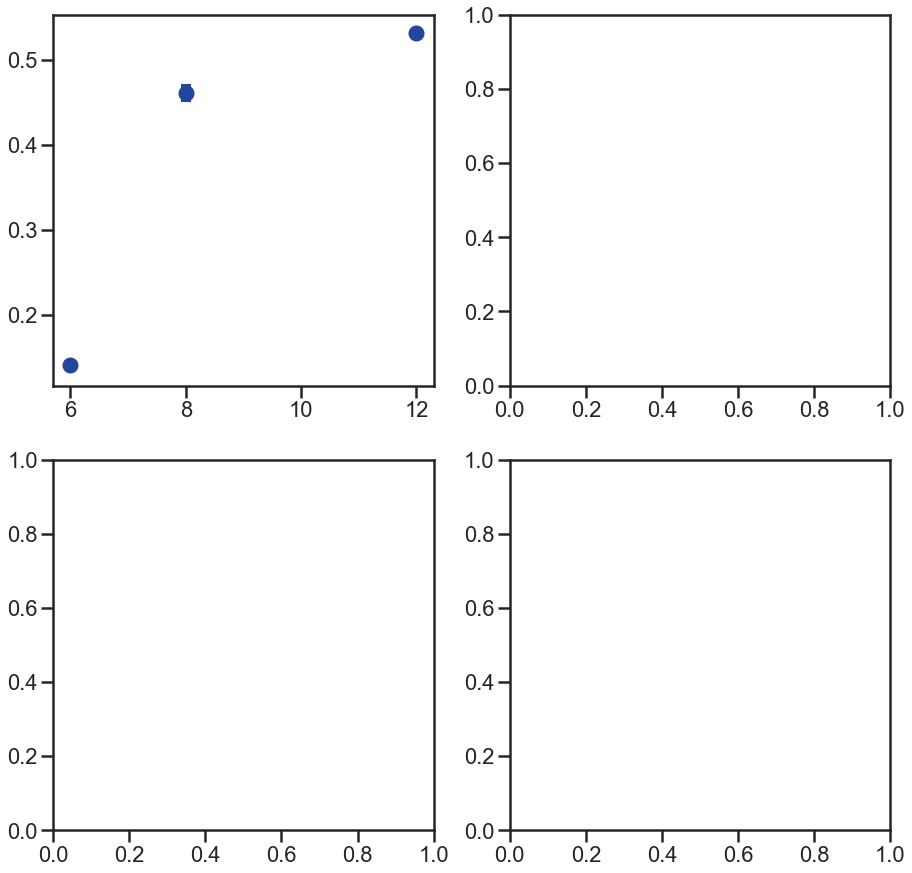

In [36]:
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]
titles = ('Growth','Nucleation','Lifetime','Correlation')
ylables = (GrowthRate,TimeToNucleate,Lifetime,TimeToNucleate)

scattersize = 12
cap = 5

fig, ax = plt.subplots(2,2,figsize=(15,15))
#     plt.suptitle('Fitted pooled data', fontsize=30)

ax[0][0].errorbar(filter_variable(tubulin, Type, 'None'), filter_parameter(GrowthRate, 'Coefficient 0' , Type, 'None' , 'Value'), 
                  yerr=filter_parameter(GrowthRate, 'Coefficient 0' , Type, 'None' , 'SE'), fmt='o', markersize=scattersize,capsize = cap,markeredgewidth=4,elinewidth=3,color=blue)
# ax[0][0].errorbar(filter_variable(tubulin, Type, 'WT'), filter_parameter(GrowthRate, 'Coefficient 0' , Type, 'WT' , 'Value'), 
#                   yerr=filter_parameter(GrowthRate, 'Coefficient 0' , Type, 'WT' , 'SE'), fmt='o', markersize=scattersize,capsize = cap,markeredgewidth=4,elinewidth=3,color=green)
# ax[0][0].errorbar(filter_variable(tubulin, Type, 'P191R'), filter_parameter(GrowthRate, 'Coefficient 0' , Type, 'P191R' , 'Value'), 
#                   yerr=filter_parameter(GrowthRate, 'Coefficient 0' , Type, 'P191R' , 'SE'), fmt='o', markersize=scattersize,capsize = cap,markeredgewidth=4,elinewidth=3,color=orange)
ax[0][0].set_ylim(0,1.5)

ax[0][1].errorbar(filter_variable(tubulin, Type, 'None'), filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'None' , 'Value'), 
                  yerr=filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'None' , 'SE'), fmt='o', markersize=scattersize,capsize = cap,markeredgewidth=4,elinewidth=3,color=blue)
# ax[0][1].errorbar(filter_variable(tubulin, Type, 'WT'), filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'WT' , 'Value'), 
#                   yerr=filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'WT' , 'SE'), fmt='o', markersize=scattersize,capsize = cap,markeredgewidth=4,elinewidth=3,color=green)
# ax[0][1].errorbar(filter_variable(tubulin, Type, 'P191R'), filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'P191R' , 'Value'), 
#                   yerr=filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'P191R' , 'SE'), fmt='o', markersize=scattersize,capsize = cap,markeredgewidth=4,elinewidth=3,color=orange)
ax[0][1].set_ylim(0,10)

ax[1][0].errorbar(filter_variable(tubulin, Type, 'None'), filter_parameter(Lifetime, 'Mean' , Type, 'None' , 'Value'), 
                  yerr=filter_parameter(Lifetime, 'Mean' , Type, 'None' , 'SE'), fmt='o', markersize=scattersize,capsize = cap,markeredgewidth=4,elinewidth=3,color=blue)
# ax[1][0].errorbar(filter_variable(tubulin, Type, 'WT'), filter_parameter(Lifetime, 'Mean' , Type, 'WT' , 'Value'), 
#                   yerr=filter_parameter(Lifetime, 'Mean' , Type, 'WT' , 'SE'), fmt='o', markersize=scattersize,capsize = cap,markeredgewidth=4,elinewidth=3,color=green)
# ax[1][0].errorbar(filter_variable(tubulin, Type, 'P191R'), filter_parameter(Lifetime, 'Mean' , Type, 'P191R' , 'Value'), 
#                   yerr=filter_parameter(Lifetime, 'Mean' , Type, 'P191R' , 'SE'), fmt='o', markersize=scattersize,capsize = cap,markeredgewidth=4,elinewidth=3,color=orange)
ax[1][0].set_ylim(0,25)

ax[1][1].errorbar( filter_parameter(Lifetime, 'Mean' , Type, 'None' , 'Value'), filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'None' , 'Value'),
                  xerr=filter_parameter(Lifetime, 'Mean' , Type, 'None' , 'SE'), yerr=filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'None' , 'SE'),
                  markeredgewidth=4,elinewidth=3,fmt='o', markersize=scattersize,capsize = cap,color=blue)
ax[1][1].errorbar(filter_parameter(Lifetime, 'Mean' , Type, 'WT' , 'Value'), filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'WT' , 'Value'), 
                  xerr=filter_parameter(Lifetime, 'Mean' , Type, 'WT' , 'SE'), yerr=filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'WT' , 'SE'),
                  markeredgewidth=4,elinewidth=3,fmt='o', markersize=scattersize,capsize = cap,color=green)
ax[1][1].errorbar(filter_parameter(Lifetime, 'Mean' , Type, 'P191R' , 'Value'), filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'P191R' , 'Value'), 
                  xerr=filter_parameter(Lifetime, 'Mean' , Type, 'P191R' , 'SE'), yerr=filter_parameter(TimeToNucleate, 'Coefficient 0' , Type, 'P191R' , 'SE'),
                  markeredgewidth=4,elinewidth=3,fmt='o', markersize=scattersize,capsize = cap,color=orange)
ax[1][1].set_ylim(0,10)




count = 0
for i in np.arange(len(ax)):
    for j in np.arange(len(ax)):
    
        ax[i][j].set_xlim(0,10)
        ax[i][j].set_xlabel(tubulin)
        ax[i][j].set_xticks(np.arange(0, 10, 2))
        ax[i][j].set_ylabel(ylables[count])
        ax[i][j].spines['right'].set_visible(False)
        ax[i][j].spines['top'].set_visible(False)
        ax[i][j].spines['left'].set_lw(3)
        ax[i][j].spines['bottom'].set_lw(3)
        ax[i][j].tick_params(axis='both', width = 3.5, length = 7)
        
        #ax[i][j].set_title(titles[count])
        
        count += 1

ax[1][1].set_xlim(0,25)
ax[1][1].set_xlabel(Lifetime)
ax[1][1].set_xticks(np.arange(0, 25, 5))
ax[i][j].legend(('None','WT','P191R'),loc='upper right',title='DCX Type')

plt.tight_layout()
#plt.savefig(path.parents[0]/('joint_graphsFit_'+jointdate+'.png'))
plt.savefig(path.parents[0]/('joint_graphsFit_corr_'+jointdate+'.pdf'))